In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 607kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [4]:
class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,400),
            nn.ReLU()

        )

        self.fc_mu = nn.Linear(400,20)

        self.fc_logvar = nn.Linear(400,20)

        self.decoder = nn.Sequential(

            nn.Linear(20,400),
            nn.ReLU(),

            nn.Linear(400,784),

            nn.Sigmoid()

        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)

        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        h = self.encoder(x)

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu,logvar)

        reconstruction = self.decoder(z)

        reconstruction = reconstruction.view(-1,1,28,28)

        return reconstruction, mu, logvar

In [5]:
model = VAE().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [6]:
def loss_function(recon, image, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon,
        image,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss

In [7]:
epochs = 10

losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,_ in train_loader:

        images = images.to(device)

        reconstruction, mu, logvar = model(images)

        loss = loss_function(
            reconstruction,
            images,
            mu,
            logvar
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader.dataset)

    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}: {epoch_loss:.4f}")

Epoch 1: 164.1208
Epoch 2: 121.3400
Epoch 3: 114.5392
Epoch 4: 111.6097
Epoch 5: 109.8961
Epoch 6: 108.7560
Epoch 7: 107.8720
Epoch 8: 107.2105
Epoch 9: 106.7383
Epoch 10: 106.2750


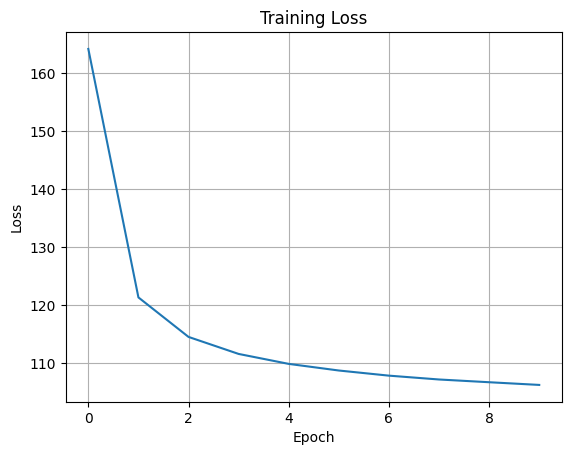

In [8]:
plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [9]:
model.eval()

image, label = next(iter(test_loader))

image = image.to(device)

start = time.time()

with torch.no_grad():

    reconstruction, mu, logvar = model(image)

end = time.time()

print("Inference Time:", end-start)

Inference Time: 0.0017807483673095703


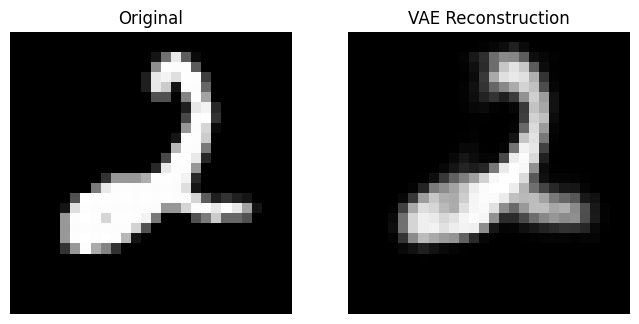

In [10]:
original = image.cpu().squeeze().numpy()

reconstructed = reconstruction.cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(121)

plt.imshow(original,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(reconstructed,cmap="gray")

plt.title("VAE Reconstruction")

plt.axis("off")

plt.show()

In [11]:
print("Mean Vector")

print(mu)

Mean Vector
tensor([[ 1.0529, -0.5708,  1.4707, -0.9244, -0.0284, -1.4390,  0.9385, -1.2007,
          0.6600,  1.3725, -1.0304,  1.1100,  1.1415, -1.3302, -0.8117,  0.8206,
         -1.1295,  0.9784, -0.1451,  1.4200]])


In [12]:
print("Log Variance")

print(logvar)

Log Variance
tensor([[-2.1651, -2.2932, -2.7907, -2.4400, -2.7538, -1.1667, -2.1447, -2.1880,
         -2.7612, -2.8052, -3.4422, -3.8180, -1.6101, -2.5448, -2.4942, -1.3687,
         -3.7071, -2.7686, -1.9382, -2.3057]])


In [13]:
mse = np.mean(
    (original-reconstructed)**2
)

print("MSE:",mse)

MSE: 0.01083841


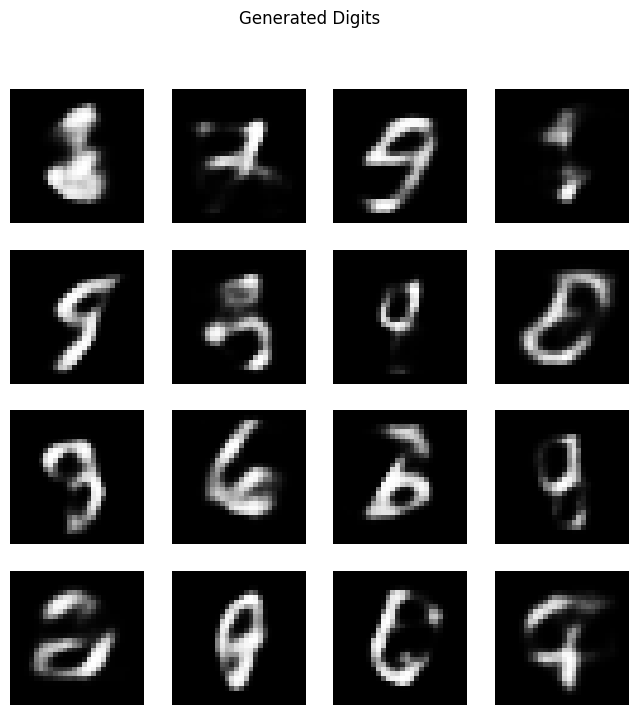

In [14]:
model.eval()

with torch.no_grad():

    z = torch.randn(16,20).to(device)

    generated = model.decoder(z)

generated = generated.view(-1,28,28).cpu().numpy()

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(generated[i],cmap="gray")

    plt.axis("off")

plt.suptitle("Generated Digits")

plt.show()